# Data Visualization: Visualization with Purpose - Accessible Data Visualization

Broken link:
https://www.visualcapitalist.com/visualizing-the-daily-routines-of-famous-creative-people/

### Flattening the curve
- small font; there is a lot of text in the image, text can be much harder to read when zoomed in
- dashed and dotted lines could be confusing
- uses jargon
- colours could be better

### Alt-text
- don't imply extra information, be descriptive
- depends on the intended purpose of an image or visualization (slide 39 for examples)

# Data Visualization: Subplots and Combining Visualizations

In [2]:
# load libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

# sample data
np.random.seed(613)
x1 = np.arange(50)
y1 = np.random.randint(0, 75,50)
x2 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y2 = np.array([110, 180, 240, 99, 220])

<BarContainer object of 5 artists>

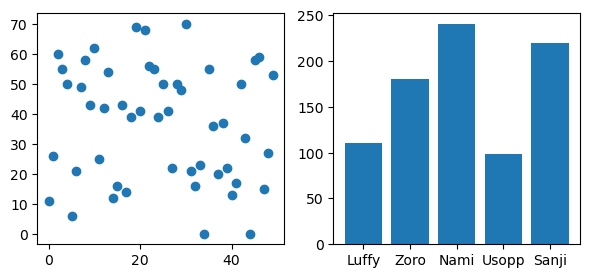

In [4]:
# define multiple axis and relative positions to have two plots next to each other
fig,(ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))

ax1.scatter(x1,y1)
ax2.bar(x2,y2)

## Activity: Customizing our plots

<BarContainer object of 5 artists>

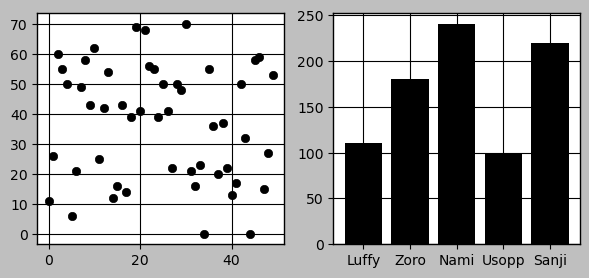

In [8]:
plt.style.use('grayscale')
fig,(ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))

ax1.scatter(x1,y1)
ax2.bar(x2,y2)

## Subplots without a grid arrangement? - Data

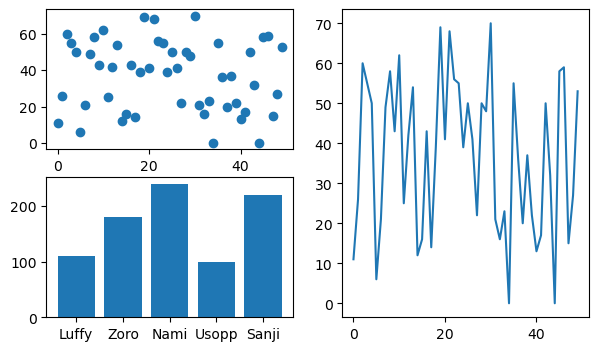

In [9]:
plt.style.use('default')

# someaxes is new, each axis we want to define has labels
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                    ['ax2', 'ax3']],
                                    figsize=(7, 4))
someaxes["ax1"].scatter(x1, y1)
someaxes["ax2"].bar(x2, y2)
someaxes["ax3"].plot(x1, y1)

Text(0.5, 0, 'Label 2: 2 Fast 2 Furious')

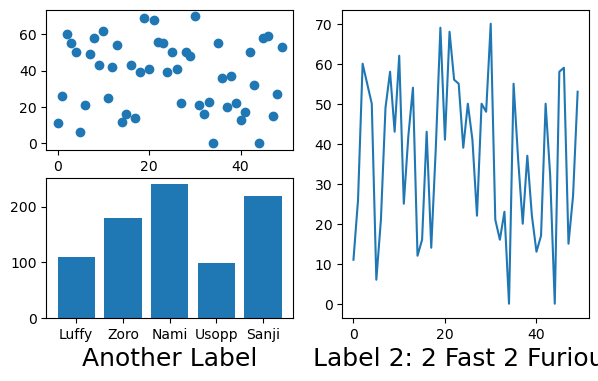

In [ ]:
# adding big titles, everything will become squished together
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                    ['ax2', 'ax3']],
                                    figsize=(7, 4))
someaxes["ax1"].scatter(x1, y1)
someaxes["ax2"].bar(x2, y2)
someaxes["ax3"].plot(x1, y1)
someaxes["ax1"].set_xlabel('A Big Label',fontsize = 18) # does not even show up
someaxes["ax2"].set_xlabel('Another Label',fontsize = 18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious',fontsize = 18) # cuts off

Text(0.5, 0, 'Label 2: 2 Fast 2 Furious')

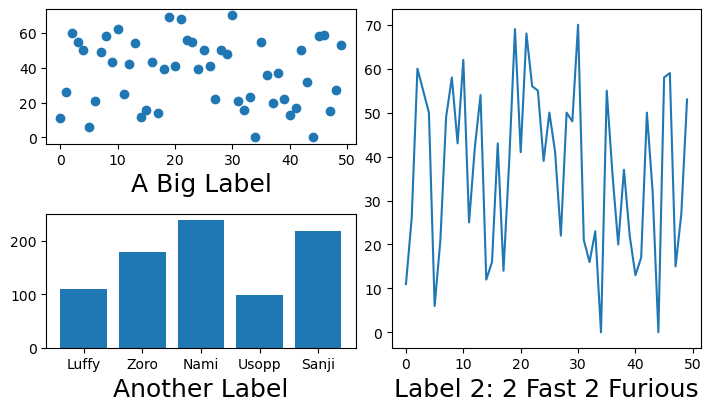

In [11]:
# to fix the above problem, using constrained layout
# tight layout - automatic adjustment to tick labels, axis labels, titles
# contrained also adjusts legends and colour labels etc
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                    ['ax2', 'ax3']],
                                    figsize=(7, 4),
                                    layout="constrained")
someaxes["ax1"].scatter(x1, y1)
someaxes["ax2"].bar(x2, y2)
someaxes["ax3"].plot(x1, y1)
someaxes["ax1"].set_xlabel('A Big Label', fontsize = 18)
someaxes["ax2"].set_xlabel('Another Label',fontsize = 18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious', fontsize = 18)

# Simplify: Multiple viz on one axes

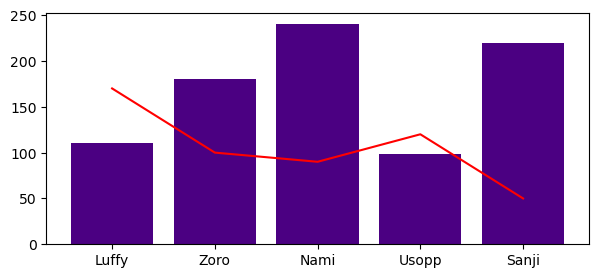

In [12]:
x = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])
y2 = np.array([170, 100, 90, 120, 50])

fig, ax = plt.subplots(figsize=(7, 3))

# call both a bar chart and plot on the same axes
ax.bar(x, y1, color = "indigo")
ax.plot(x, y2, color = "red")

## Add error information

<ErrorbarContainer object of 3 artists>

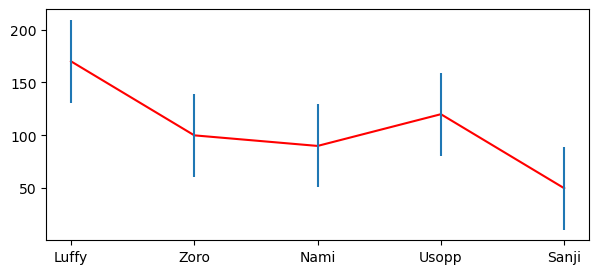

In [15]:
# calculate std
y2_sd = np.std(y2)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")

ax.errorbar(x, y2, yerr = y2_sd, fmt = "none")

<ErrorbarContainer object of 3 artists>

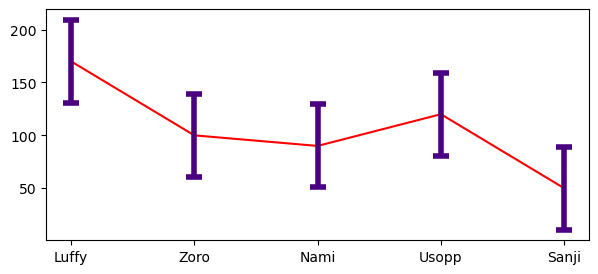

In [20]:
# customize error bar appearance
y2_sd = np.std(y2)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")

ax.errorbar(x, y2, yerr = y2_sd, fmt = "none",
            ecolor = 'indigo',
            elinewidth = 4,
            capsize = 6,
            capthick = 4
            #,errorevery = 3
            )

# Adding images to plots

In [21]:
# load libraries
from PIL import Image 
from io import BytesIO

In [22]:
response = requests.get('https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png')
image_file = BytesIO(response.content)
image = Image.open(image_file)

(-0.5, 219.5, 425.5, -0.5)

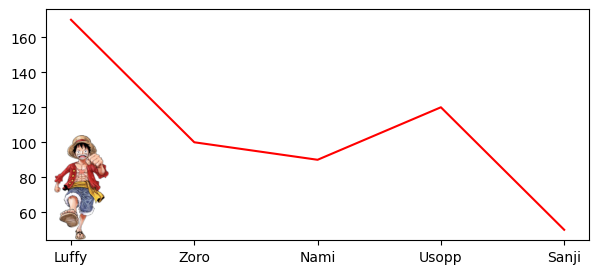

In [26]:
fig, ax = plt.subplots(figsize = (7,3))
ax.plot(x, y2, color='red')

ax_image = fig.add_axes([0.1, 0.11, 0.15, 0.35]) # first x coordinate, second y coordinate (these are based on figure), third image width, fourth image height

# getting rid of the borders and adding image
ax_image.imshow(image)
ax_image.axis("off")

### Saving plots

Visual Studio Code allows you to save the plots directly, but slide 33 shows how to manually save a visualization.